In [1]:
from __future__ import annotations
import os
from pathlib import Path
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện quan trọng 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Optional: pip install yellowbrick (giúp vẽ Elbow đẹp hơn)
try:
    from yellowbrick.cluster import KElbowVisualizer
except ImportError:
    print("Cài đặt 'pip install yellowbrick' để vẽ biểu đồ Elbow chuyên nghiệp hơn.")








In [2]:
#1. Cấu hình chung cho dự án
class HMConfig:
    # Nếu chạy trên Colab thì giữ nguyên, nếu chạy PyCharm thì sửa đường dẫn này
    DRIVE_PATH = Path("")

    # Thư mục chứa kết quả của Tuần 1
    OUTPUT_DIR = Path("./outputs")

    # Các file dữ liệu sạch đã tạo từ Tuần 1
    RFM_CLEAN_PATH = OUTPUT_DIR / "customer_rfm_clean.parquet"
    CUSTOMERS_CLEAN_PATH = OUTPUT_DIR / "customers_clean.parquet"

    @classmethod
    def setup(cls):
        # Thiết lập hiển thị biểu đồ
        plt.rcParams["figure.figsize"] = (12, 6)
        sns.set_theme(style="whitegrid")

        if not cls.OUTPUT_DIR.exists():
            print(f"Cảnh báo: Không tìm thấy thư mục {cls.OUTPUT_DIR}. Hãy đảm bảo bạn đã chạy code Tuần 1!")
            # Khởi tạo cấu hình
HMConfig.setup()

In [3]:

#2. Nạp dữ liệu và tiền xử lý
def load_and_preprocess_data() -> Tuple[pd.DataFrame, np.ndarray]:
    """
    Nạp dữ liệu RFM và thực hiện các bước biến đổi toán học.
    """
    print("--- Đang nạp dữ liệu RFM từ Tuần 1 ---")

    # 1. Đọc file Parquet bằng Polars để tối ưu tốc độ
    if not HMConfig.RFM_CLEAN_PATH.exists():
        raise FileNotFoundError(f"Không tìm thấy file tại {HMConfig.RFM_CLEAN_PATH}. Hãy chạy lại Tuần 1!")

    rfm_df = pl.read_parquet(HMConfig.RFM_CLEAN_PATH)

    # Chuyển sang Pandas để tương thích với Scikit-learn
    rfm_pd = rfm_df.to_pandas().copy()

    # 2. Log Transformation (np.log1p)
    # Giúp đưa dữ liệu bị lệch về phân phối chuẩn hơn
    print("--- Thực hiện Log Transformation cho R, F, M ---")
    for col in ['recency', 'frequency', 'monetary']:
        rfm_pd[f"{col}_log"] = np.log1p(rfm_pd[col])

    # 3. Chuẩn hóa StandardScaler
    # Đưa dữ liệu về giá trị trung bình = 0 và độ lệch chuẩn = 1
    print("--- Chuẩn hóa dữ liệu bằng StandardScaler ---")
    features_log = ['recency_log', 'frequency_log', 'monetary_log']
    X_log = rfm_pd[features_log]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_log)

    # Lưu lại giá trị đã scale vào DataFrame để vẽ biểu đồ sau này
    rfm_pd[['recency_scaled', 'frequency_scaled', 'monetary_scaled']] = X_scaled

    print(f"Đã nạp và tiền xử lý xong cho {rfm_pd.shape[0]} khách hàng.")
    return rfm_pd, X_scaled

# --- Thực thi thử nghiệm ---
# rfm_pd, X_scaled = load_and_preprocess_data() (Chỉ chạy để kiểm tra)

In [4]:
#3. Tìm số cụm K tối ưu
def find_optimal_k(X_scaled: np.ndarray, max_k: int = 10):
    """
    Sử dụng Elbow Method (Phương pháp Khuỷu tay) để xác định số cụm K.
    Đầu vào: X_scaled (Dữ liệu đã chuẩn hóa từ Bước 2).
    """
    print(f"--- Đang chạy Elbow Method với K từ 1 đến {max_k} ---")

    # Tính WCSS (Tổng bình phương khoảng cách trong cụm)
    wcss = []
    for i in range(1, max_k + 1):
        # n_init=10: Chạy 10 lần với các tâm cụm ngẫu nhiên để chọn kết quả tốt nhất
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_) # inertia_ chính là WCSS

    # Vẽ biểu đồ Elbow
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--', color='b')

    # Chú thích điểm gãy (Thường K tối ưu nằm ở nơi đường cong bắt đầu phẳng đi)
    plt.title('Biểu đồ Elbow Method để chọn K tối ưu', fontsize=14)
    plt.xlabel('Số lượng cụm (K)')
    plt.ylabel('WCSS (Inertia)')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True, alpha=0.3)

    # Lưu biểu đồ vào thư mục outputs để đưa vào báo cáo
    plt.savefig(HMConfig.OUTPUT_DIR / "elbow_method_plot.png")
    plt.show()

    print(f"Biểu đồ Elbow đã được lưu tại {HMConfig.OUTPUT_DIR}")


In [5]:

#4. Thực thi K-Means & Gán nhãn cụm
def perform_kmeans_clustering(rfm_pd: pd.DataFrame, X_scaled: np.ndarray, k: int) -> pd.DataFrame:
    """
    Thực hiện phân cụm K-Means với số cụm k tối ưu.
    """
    print(f"--- Đang thực thi K-Means với K = {k} ---")

    # 1. Khởi tạo và huấn luyện mô hình
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    rfm_pd['Cluster'] = kmeans.fit_predict(X_scaled)

    # 2. Thống kê đặc trưng các cụm (Dùng giá trị thực để dễ hiểu)
    # Chúng ta xem trung bình Recency (ngày), Frequency (lần), Monetary (tiền)
    cluster_profile = rfm_pd.groupby('Cluster').agg({
        'recency': 'mean',
        'frequency': 'mean',
        'monetary': 'mean'
    }).sort_values(by='monetary', ascending=False) # Sắp xếp theo mức chi tiêu

    print("\n📊 BẢNG ĐẶC TRƯNG TRUNG BÌNH CÁC CỤM:")
    print(cluster_profile)

    # 3. Lưu bảng RFM đã phân cụm để dùng cho Tuần 3
    output_path = HMConfig.OUTPUT_DIR / "customer_segments_final.parquet"
    pl.from_pandas(rfm_pd).write_parquet(output_path)

    print(f"\n Đã lưu kết quả phân cụm tại: {output_path}")
    return rfm_pd


In [6]:

#5. Vẽ Snake Plot để giải mã hành vi
def plot_snake_plot(rfm_pd: pd.DataFrame):
    """
    Vẽ Snake Plot để so sánh đặc trưng R-F-M giữa các cụm.
    Sử dụng dữ liệu đã chuẩn hóa (scaled) để các đường nằm trên cùng một thang đo.
    """
    print("--- Đang vẽ Snake Plot để giải mã đặc trưng các cụm ---")

    # 1. Chuẩn bị dữ liệu dạng "Long format" để Seaborn dễ xử lý
    # Chỉ lấy các cột đã scale và nhãn Cluster
    features_scaled = ['recency_scaled', 'frequency_scaled', 'monetary_scaled']

    # Chuyển bảng từ dạng ngang sang dạng dọc
    df_melt = pd.melt(
        rfm_pd.reset_index(),
        id_vars=['Cluster'],
        value_vars=features_scaled,
        var_name='Metric',
        value_name='Value'
    )

    # Đổi tên Metric cho đẹp trên biểu đồ
    df_melt['Metric'] = df_melt['Metric'].replace({
        'recency_scaled': 'Recency',
        'frequency_scaled': 'Frequency',
        'monetary_scaled': 'Monetary'
    })

    # 2. Vẽ biểu đồ đường (Line Plot)
    plt.figure(figsize=(12, 7))
    sns.lineplot(data=df_melt, x='Metric', y='Value', hue='Cluster', palette='bright', marker='o', linewidth=2)

    plt.title('Snake Plot: So sánh đặc trưng RFM giữa các cụm khách hàng', fontsize=15)
    plt.xlabel('Chỉ số RFM', fontsize=12)
    plt.ylabel('Giá trị đã chuẩn hóa (Z-Score)', fontsize=12)
    plt.legend(title='Cụm', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Lưu biểu đồ
    plt.savefig(HMConfig.OUTPUT_DIR / "rfm_snake_plot.png")
    plt.show()

    print(f" Biểu đồ Snake Plot đã được lưu tại {HMConfig.OUTPUT_DIR}")

In [7]:

#6. Phân tích Nhân khẩu học theo cụm
def analyze_cluster_demographics(rfm_pd: pd.DataFrame):
    """
    Hợp nhất nhãn cụm với thông tin tuổi và trạng thái thành viên.
    """
    print("--- Đang phân tích đặc điểm nhân khẩu học theo từng cụm ---")

    # 1. Nạp lại bảng khách hàng sạch từ Tuần 1
    if not HMConfig.CUSTOMERS_CLEAN_PATH.exists():
        print("Cảnh báo: Không tìm thấy file khách hàng sạch. Bỏ qua bước này.")
        return

    customers_clean = pl.read_parquet(HMConfig.CUSTOMERS_CLEAN_PATH)

    # 2. Hợp nhất (Merge) nhãn cụm vào thông tin khách hàng
    # rfm_pd đang ở dạng Pandas, ta chuyển sang Polars để join cho nhanh
    final_df = (
        pl.from_pandas(rfm_pd)
        .join(customers_clean, on="customer_id", how="inner")
    ).collect_schema() # Kiểm tra schema

    final_df = pl.from_pandas(rfm_pd).join(customers_clean, on="customer_id", how="inner")

    # 3. Thống kê độ tuổi và Membership theo Cụm
    # Chuyển về Pandas để dùng groupby tiện lợi cho việc in ấn
    final_pd = final_df.to_pandas()

    demo_stats = final_pd.groupby('Cluster').agg({
        'age': 'mean',
        'club_member_status': lambda x: x.value_counts().index[0] # Trạng thái phổ biến nhất
    }).rename(columns={'age': 'Độ tuổi trung bình', 'club_member_status': 'Membership phổ biến'})

    print("\n👥 ĐẶC ĐIỂM NHÂN KHẨU HỌC:")
    print(demo_stats)

    # 4. Vẽ biểu đồ phân phối tuổi theo cụm
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=final_pd, x='Cluster', y='age', palette='Set3')
    plt.title('Phân phối độ tuổi theo từng cụm khách hàng', fontsize=14)
    plt.grid(axis='y', alpha=0.3)

    plt.savefig(HMConfig.OUTPUT_DIR / "cluster_age_distribution.png")
    plt.show()

    return final_pd

--- Đang nạp dữ liệu RFM từ Tuần 1 ---
--- Thực hiện Log Transformation cho R, F, M ---
--- Chuẩn hóa dữ liệu bằng StandardScaler ---
Đã nạp và tiền xử lý xong cho 837609 khách hàng.
--- Đang thực thi K-Means với K = 4 ---

📊 BẢNG ĐẶC TRƯNG TRUNG BÌNH CÁC CỤM:
            recency  frequency  monetary
Cluster                                 
1         23.271043  46.595932  1.340140
2         76.620794  14.559790  0.367941
3         11.672706   8.606550  0.226840
0        125.485560   3.236711  0.083545

 Đã lưu kết quả phân cụm tại: outputs\customer_segments_final.parquet
--- Đang vẽ Snake Plot để giải mã đặc trưng các cụm ---


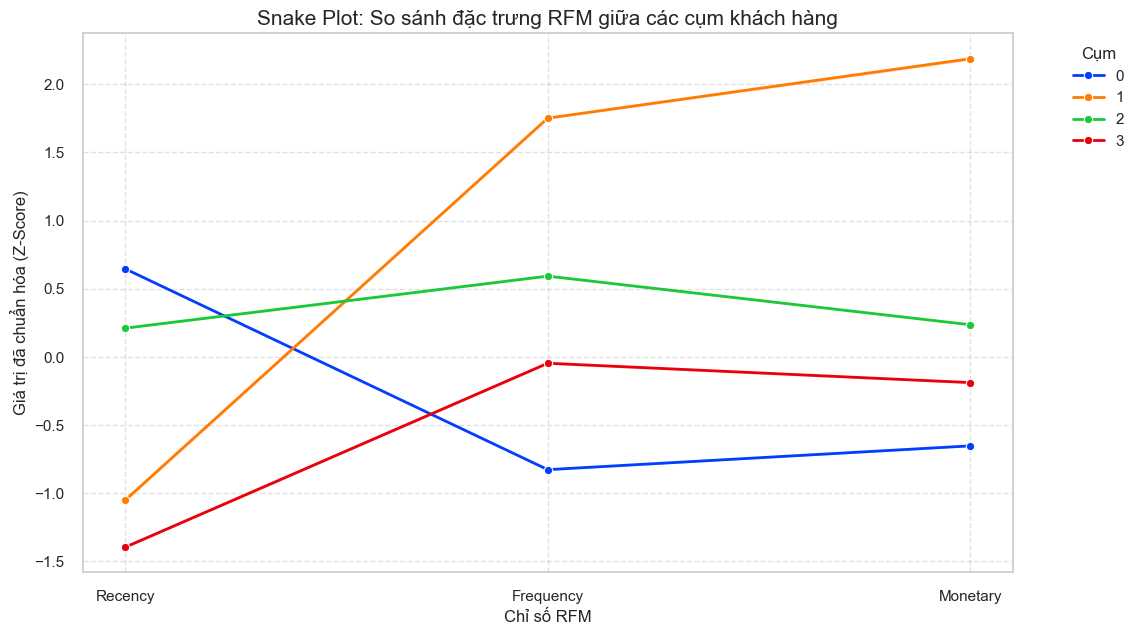

 Biểu đồ Snake Plot đã được lưu tại outputs
--- Đang phân tích đặc điểm nhân khẩu học theo từng cụm ---

👥 ĐẶC ĐIỂM NHÂN KHẨU HỌC:
         Độ tuổi trung bình Membership phổ biến
Cluster                                        
0                 35.620758              ACTIVE
1                 35.659351              ACTIVE
2                 34.867088              ACTIVE
3                 35.147446              ACTIVE


C:\Users\Admin\AppData\Local\Temp\ipykernel_14392\2174639992.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_pd, x='Cluster', y='age', palette='Set3')


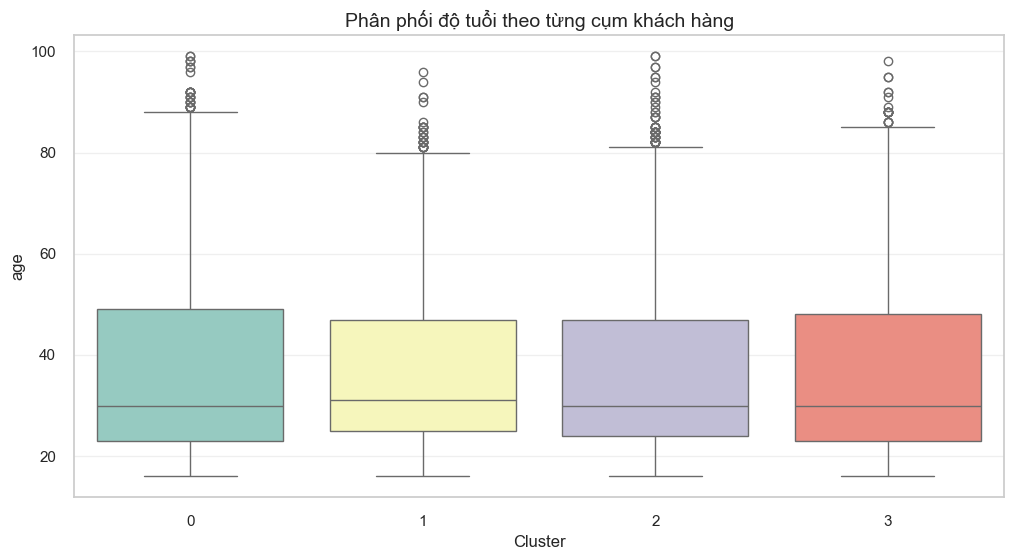

In [8]:

#7. Hàm thực thi chính
if __name__ == "__main__":
    # Bước 1: Nạp và tiền xử lý
    rfm_pd, X_scaled = load_and_preprocess_data()

    # Bước 2: Chạy Elbow để tìm K (Bạn chạy lần đầu, xem hình rồi chọn K)
    #find_optimal_k(X_scaled)
#Biểu đồ Elbow cho thấy WCSS giảm mạnh từ K=1 đến K=4, sau đó giảm chậm dần. Điều này cho thấy việc tăng số cụm sau K=4 #không mang lại nhiều cải thiện, vì vậy chúng tôi chọn K=4 là số cụm tối ưu
    # Bước 3: Sau khi chọn được K (ví dụ K=4), comment dòng Elbow và chạy dòng dưới
    K_OPTIMAL = 4
    rfm_clustered = perform_kmeans_clustering(rfm_pd, X_scaled, k=K_OPTIMAL)

    # Bước 4: Vẽ biểu đồ giải mã (Snake Plot)
    plot_snake_plot(rfm_clustered)

    # Bước 5: Phân tích nhân khẩu học
    final_data = analyze_cluster_demographics(rfm_clustered)